<a href="https://colab.research.google.com/github/NatashaMyruta/Machine-Learning/blob/main/%D0%9B%D0%9112_%D0%9C%D0%9D_%D0%9C%D0%B8%D1%80%D1%83%D1%82%D0%B0.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Мирута Наталія Романівна ФІТ 3-15

In [7]:
!pip install kagglehub -q
!pip install -q kagglehub tensorflow matplotlib seaborn scikit-learn
!pip install opencv-python

## Підключення необхідних модулів

In [8]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import os, random, cv2, warnings
warnings.filterwarnings('ignore')

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models, callbacks, regularizers
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.utils import to_categorical

from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import train_test_split

# Фіксація генераторів випадковості для повторюваності
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)
random.seed(SEED)

print(f'TensorFlow version: {tf.__version__}')
print(f'GPU available: {len(tf.config.list_physical_devices("GPU")) > 0}')

TensorFlow version: 2.21.0
GPU available: False



#  ЗАВДАННЯ 1: Fashion MNIST — Класифікація типів одягу


## 1.1 Читання та попередня обробка даних

In [9]:
(X_train_raw, y_train_raw), (X_test_raw, y_test_raw) = keras.datasets.fashion_mnist.load_data()

CLASS_NAMES_FASHION = [
    'T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
    'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot'
]

print(f'Train: {X_train_raw.shape}, Test: {X_test_raw.shape}')
print(f'Кількість класів: {len(CLASS_NAMES_FASHION)}')

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Train: (60000, 28, 28), Test: (10000, 28, 28)
Кількість класів: 10


In [10]:
X_train_f = X_train_raw.reshape(-1, 28, 28, 1).astype('float32') / 255.0
X_test_f  = X_test_raw.reshape(-1, 28, 28, 1).astype('float32') / 255.0

X_train_f, X_val_f, y_train_f, y_val_f = train_test_split(
    X_train_f, y_train_raw, test_size=0.15, random_state=SEED, stratify=y_train_raw
)

y_test_f = y_test_raw

print(f'Train: {X_train_f.shape}  |  Val: {X_val_f.shape}  |  Test: {X_test_f.shape}')

Train: (51000, 28, 28, 1)  |  Val: (9000, 28, 28, 1)  |  Test: (10000, 28, 28, 1)


## 1.2 Огляд зразків датасету

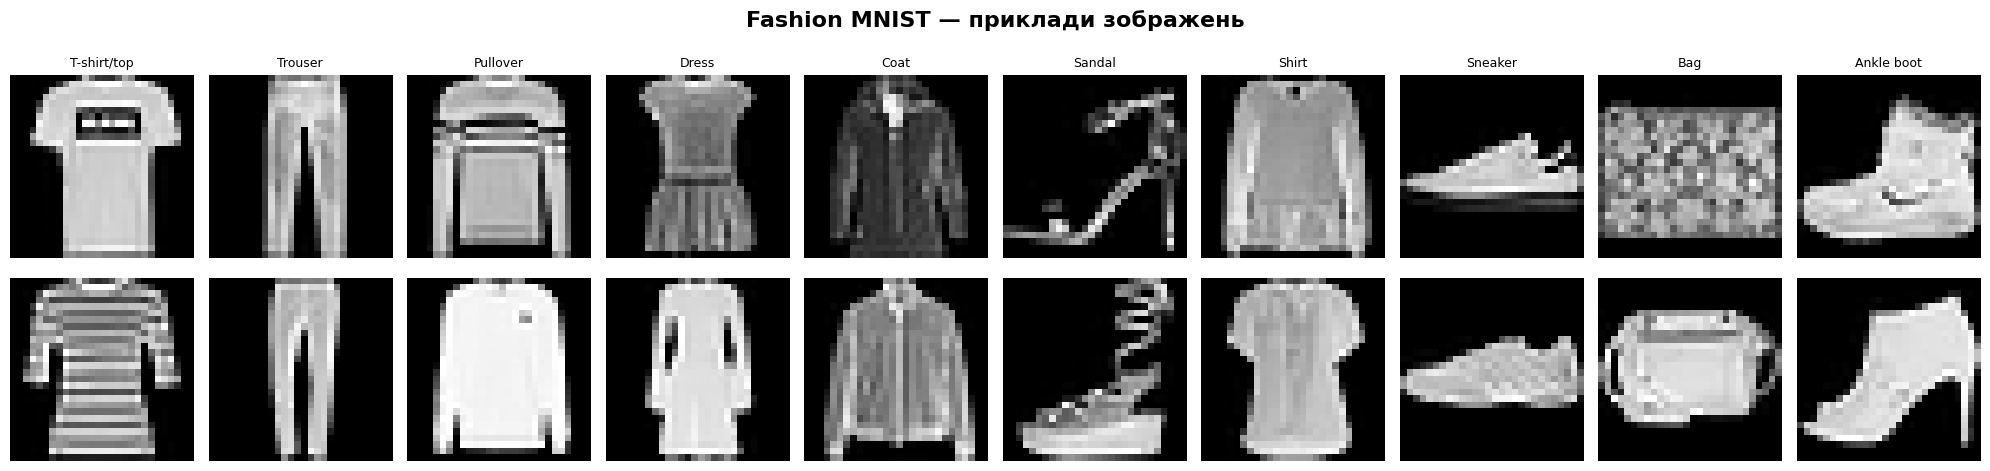

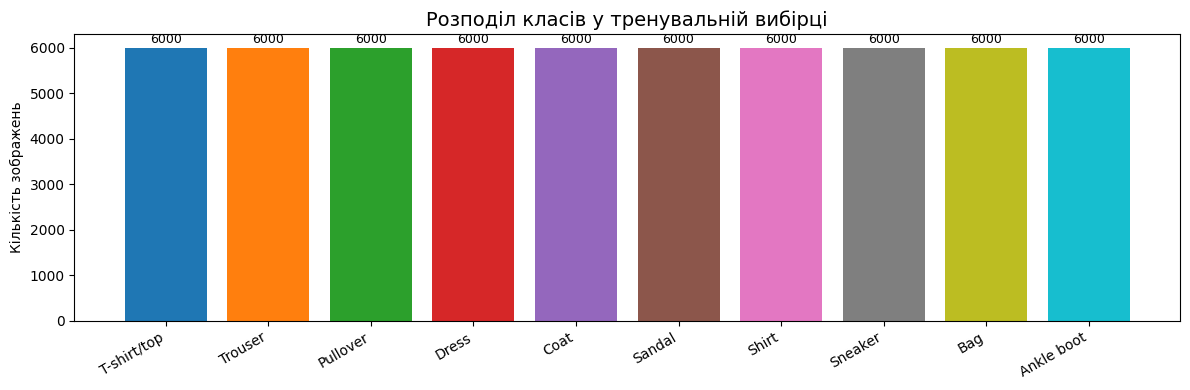

In [11]:
fig, axes = plt.subplots(2, 10, figsize=(20, 5))
fig.suptitle('Fashion MNIST — приклади зображень', fontsize=16, fontweight='bold')

for cls in range(10):
    idx = np.where(y_train_raw == cls)[0][0]
    axes[0, cls].imshow(X_train_raw[idx], cmap='gray')
    axes[0, cls].set_title(CLASS_NAMES_FASHION[cls], fontsize=9)
    axes[0, cls].axis('off')

    idx2 = np.where(y_train_raw == cls)[0][5]
    axes[1, cls].imshow(X_train_raw[idx2], cmap='gray')
    axes[1, cls].axis('off')

plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(12, 4))
unique, counts = np.unique(y_train_raw, return_counts=True)
bars = ax.bar([CLASS_NAMES_FASHION[i] for i in unique], counts, color=plt.cm.tab10.colors)
ax.set_title('Розподіл класів у тренувальній вибірці', fontsize=14)
ax.set_ylabel('Кількість зображень')
ax.set_xticklabels([CLASS_NAMES_FASHION[i] for i in unique], rotation=30, ha='right')
for bar, count in zip(bars, counts):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 30,
            str(count), ha='center', va='bottom', fontsize=9)
plt.tight_layout()
plt.show()

## 1.3 Визначення архітектури згорткової мережі

In [12]:
def create_fashion_model(input_shape=(28, 28, 1), num_classes=10):
    model = models.Sequential([

        layers.Conv2D(32, (3, 3), padding='same', input_shape=input_shape),
        layers.BatchNormalization(),
        layers.Activation('relu'),
        layers.Conv2D(32, (3, 3), padding='same'),
        layers.BatchNormalization(),
        layers.Activation('relu'),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.25),


        layers.Conv2D(64, (3, 3), padding='same'),
        layers.BatchNormalization(),
        layers.Activation('relu'),
        layers.Conv2D(64, (3, 3), padding='same'),
        layers.BatchNormalization(),
        layers.Activation('relu'),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.30),


        layers.Conv2D(128, (3, 3), padding='same'),
        layers.BatchNormalization(),
        layers.Activation('relu'),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.35),


        layers.GlobalAveragePooling2D(),
        layers.Dense(192, kernel_regularizer=regularizers.l2(1e-4)),
        layers.BatchNormalization(),
        layers.Activation('relu'),
        layers.Dropout(0.5),
        layers.Dense(num_classes, activation='softmax')
    ], name='FashionNet')
    return model

model_fashion = create_fashion_model()
model_fashion.summary()

Model: "FashionNet"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 28, 28, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 28, 28, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 28, 28, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 28, 28, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 28, 28, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 14, 14, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 14, 14, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 14, 14, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 7, 7, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 7, 7, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_4 (Activation)       │ (None, 7, 7, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 3, 3, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 3, 3, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │             

 Total params: 167,594 (654.66 KB)

 Trainable params: 166,570 (650.66 KB)

 Non-trainable params: 1,024 (4.00 KB)

## 1.4 Налаштування та запуск навчання

In [13]:

aug_fashion = ImageDataGenerator(
    rotation_range=10,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True,
    zoom_range=0.1
)
aug_fashion.fit(X_train_f)


model_fashion.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)


es_cb = callbacks.EarlyStopping(
    monitor='val_accuracy', patience=7, restore_best_weights=True, verbose=1
)
rlr_cb = callbacks.ReduceLROnPlateau(
    monitor='val_loss', factor=0.5, patience=4, min_lr=1e-6, verbose=1
)
ckpt_cb = callbacks.ModelCheckpoint(
    'best_fashion_cnn.keras', save_best_only=True, monitor='val_accuracy', verbose=0
)

BATCH_SIZE = 64
EPOCHS     = 30

history_fashion = model_fashion.fit(
    aug_fashion.flow(X_train_f, y_train_f, batch_size=BATCH_SIZE, seed=SEED),
    steps_per_epoch=len(X_train_f) // BATCH_SIZE,
    epochs=EPOCHS,
    validation_data=(X_val_f, y_val_f),
    callbacks=[es_cb, rlr_cb, ckpt_cb],
    verbose=1
)

Epoch 1/30
796/796 ━━━━━━━━━━━━━━━━━━━━ 157s 193ms/step - accuracy: 0.6879 - loss: 0.8679 - val_accuracy: 0.7749 - val_loss: 0.6356 - learning_rate: 0.0010
Epoch 2/30
796/796 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.8438 - loss: 0.4923 - val_accuracy: 0.7606 - val_loss: 0.6778 - learning_rate: 0.0010
Epoch 3/30
796/796 ━━━━━━━━━━━━━━━━━━━━ 149s 188ms/step - accuracy: 0.7889 - loss: 0.5852 - val_accuracy: 0.8143 - val_loss: 0.5392 - learning_rate: 0.0010
Epoch 4/30
796/796 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.8281 - loss: 0.4915 - val_accuracy: 0.8119 - val_loss: 0.5424 - learning_rate: 0.0010
Epoch 5/30
796/796 ━━━━━━━━━━━━━━━━━━━━ 148s 186ms/step - accuracy: 0.8200 - loss: 0.5062 - val_accuracy: 0.8603 - val_loss: 0.3901 - learning_rate: 0.0010
Epoch 6/30
796/796 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.8594 - loss: 0.3858 - val_accuracy: 0.8610 - val_loss: 0.3857 - learning_rate: 0.0010
Epoch 7/30
796/796 ━━━━━━━━━━━━━━━━━━━━ 147s 185ms/step - accuracy: 0.8344 -

## 1.5 Динаміка навчального процесу

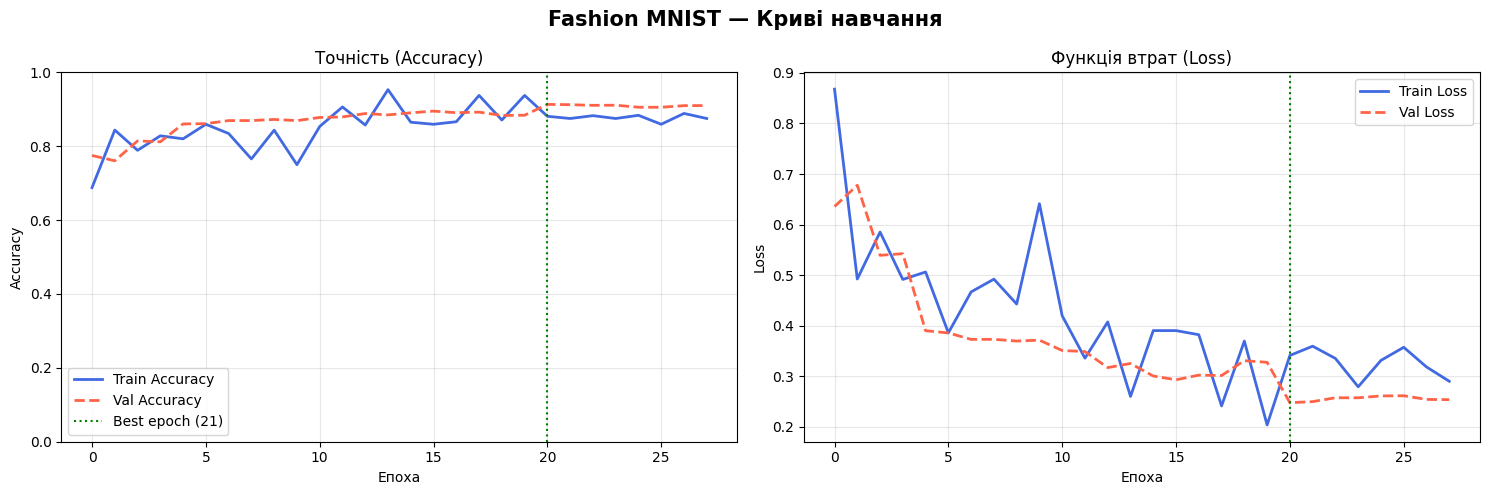

In [14]:
def visualize_training(history, title='Криві навчання'):
    fig, axes = plt.subplots(1, 2, figsize=(15, 5))
    fig.suptitle(title, fontsize=15, fontweight='bold')


    axes[0].plot(history.history['accuracy'],     label='Train Accuracy', linewidth=2, color='royalblue')
    axes[0].plot(history.history['val_accuracy'], label='Val Accuracy',   linewidth=2, color='tomato', linestyle='--')
    best_epoch = np.argmax(history.history['val_accuracy'])
    axes[0].axvline(best_epoch, color='green', linestyle=':', label=f'Best epoch ({best_epoch+1})')
    axes[0].set_title('Точність (Accuracy)')
    axes[0].set_xlabel('Епоха')
    axes[0].set_ylabel('Accuracy')
    axes[0].legend()
    axes[0].grid(alpha=0.3)
    axes[0].set_ylim([0, 1])


    axes[1].plot(history.history['loss'],     label='Train Loss', linewidth=2, color='royalblue')
    axes[1].plot(history.history['val_loss'], label='Val Loss',   linewidth=2, color='tomato', linestyle='--')
    axes[1].axvline(np.argmin(history.history['val_loss']), color='green', linestyle=':')
    axes[1].set_title('Функція втрат (Loss)')
    axes[1].set_xlabel('Епоха')
    axes[1].set_ylabel('Loss')
    axes[1].legend()
    axes[1].grid(alpha=0.3)

    plt.tight_layout()
    plt.show()


    if 'lr' in history.history:
        plt.figure(figsize=(8, 3))
        plt.plot(history.history['lr'], color='purple', linewidth=2)
        plt.title('Швидкість навчання (Learning Rate)')
        plt.xlabel('Епоха')
        plt.ylabel('LR')
        plt.yscale('log')
        plt.grid(alpha=0.3)
        plt.tight_layout()
        plt.show()

visualize_training(history_fashion, title='Fashion MNIST — Криві навчання')

## 1.6 Тестування моделі

In [15]:
test_loss, test_acc = model_fashion.evaluate(X_test_f, y_test_f, verbose=0)
print(f'\n{'='*50}')
print(f'  Test Loss:     {test_loss:.4f}')
print(f'  Test Accuracy: {test_acc:.4f} ({test_acc*100:.2f}%)')
print(f'{'='*50}')

y_pred_f = np.argmax(model_fashion.predict(X_test_f, verbose=0), axis=1)

print('\nЗвіт класифікації:')
print(classification_report(y_test_f, y_pred_f, target_names=CLASS_NAMES_FASHION))


  Test Loss:     0.2776
  Test Accuracy: 0.9049 (90.49%)

Звіт класифікації:
              precision    recall  f1-score   support

 T-shirt/top       0.90      0.78      0.84      1000
     Trouser       0.99      0.98      0.99      1000
    Pullover       0.91      0.84      0.87      1000
       Dress       0.91      0.90      0.91      1000
        Coat       0.79      0.92      0.85      1000
      Sandal       0.99      0.97      0.98      1000
       Shirt       0.70      0.73      0.72      1000
     Sneaker       0.94      0.97      0.96      1000
         Bag       0.98      0.99      0.99      1000
  Ankle boot       0.97      0.95      0.96      1000

    accuracy                           0.90     10000
   macro avg       0.91      0.90      0.91     10000
weighted avg       0.91      0.90      0.91     10000



## 1.7 Аналіз матриці плутанини

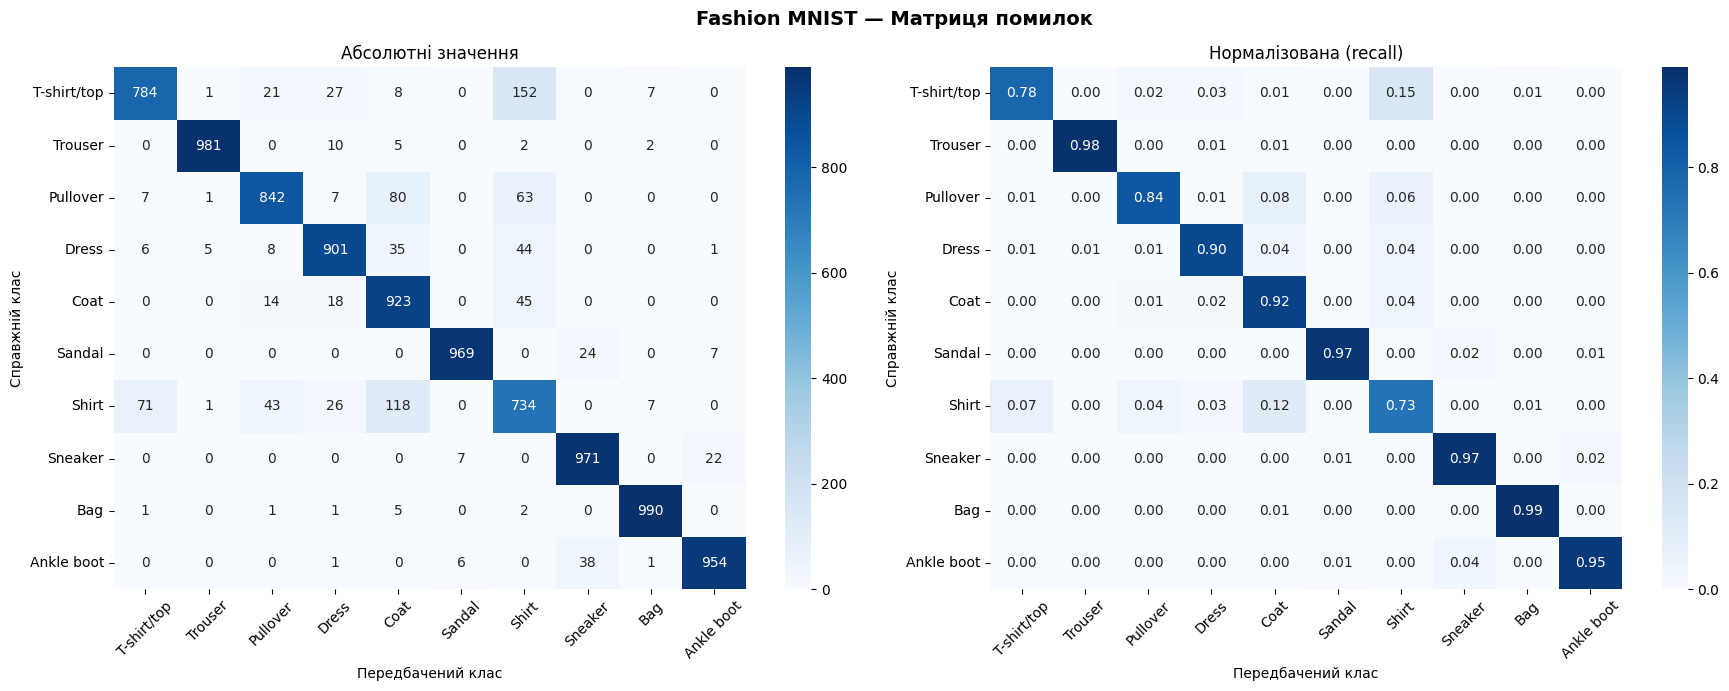

In [16]:
cm = confusion_matrix(y_test_f, y_pred_f)
cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

fig, axes = plt.subplots(1, 2, figsize=(18, 7))
fig.suptitle('Fashion MNIST — Матриця помилок', fontsize=14, fontweight='bold')

for ax, data, fmt, title in zip(
    axes,
    [cm, cm_norm],
    ['d', '.2f'],
    ['Абсолютні значення', 'Нормалізована (recall)']
):
    sns.heatmap(data, annot=True, fmt=fmt, cmap='Blues', ax=ax,
                xticklabels=CLASS_NAMES_FASHION, yticklabels=CLASS_NAMES_FASHION)
    ax.set_title(title)
    ax.set_ylabel('Справжній клас')
    ax.set_xlabel('Передбачений клас')
    ax.tick_params(axis='x', rotation=45)
    ax.tick_params(axis='y', rotation=0)

plt.tight_layout()
plt.show()

## 1.8 Приклади класифікації зображень

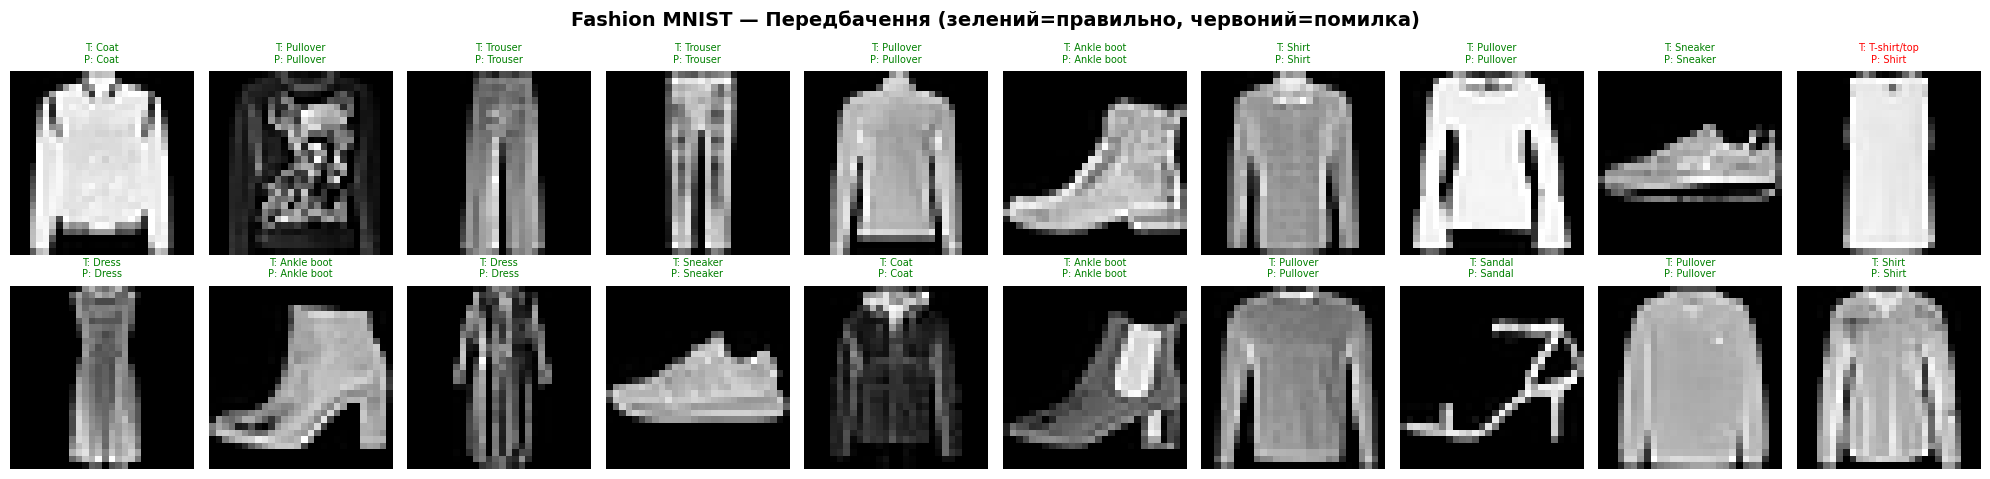

In [17]:
def plot_predictions(X, y_true, y_pred, class_names, n=20, title='Передбачення моделі'):
    indices = random.sample(range(len(X)), n)
    cols = 10
    rows = n // cols
    fig, axes = plt.subplots(rows, cols, figsize=(cols * 2, rows * 2.5))
    fig.suptitle(title, fontsize=14, fontweight='bold')

    for i, idx in enumerate(indices):
        ax = axes[i // cols][i % cols]
        img = X[idx].squeeze()
        ax.imshow(img, cmap='gray')
        true_label = class_names[y_true[idx]]
        pred_label = class_names[y_pred[idx]]
        color = 'green' if y_true[idx] == y_pred[idx] else 'red'
        ax.set_title(f'T: {true_label}\nP: {pred_label}', fontsize=7, color=color)
        ax.axis('off')

    plt.tight_layout()
    plt.show()

plot_predictions(X_test_f, y_test_f, y_pred_f, CLASS_NAMES_FASHION,
                 n=20, title='Fashion MNIST — Передбачення (зелений=правильно, червоний=помилка)')

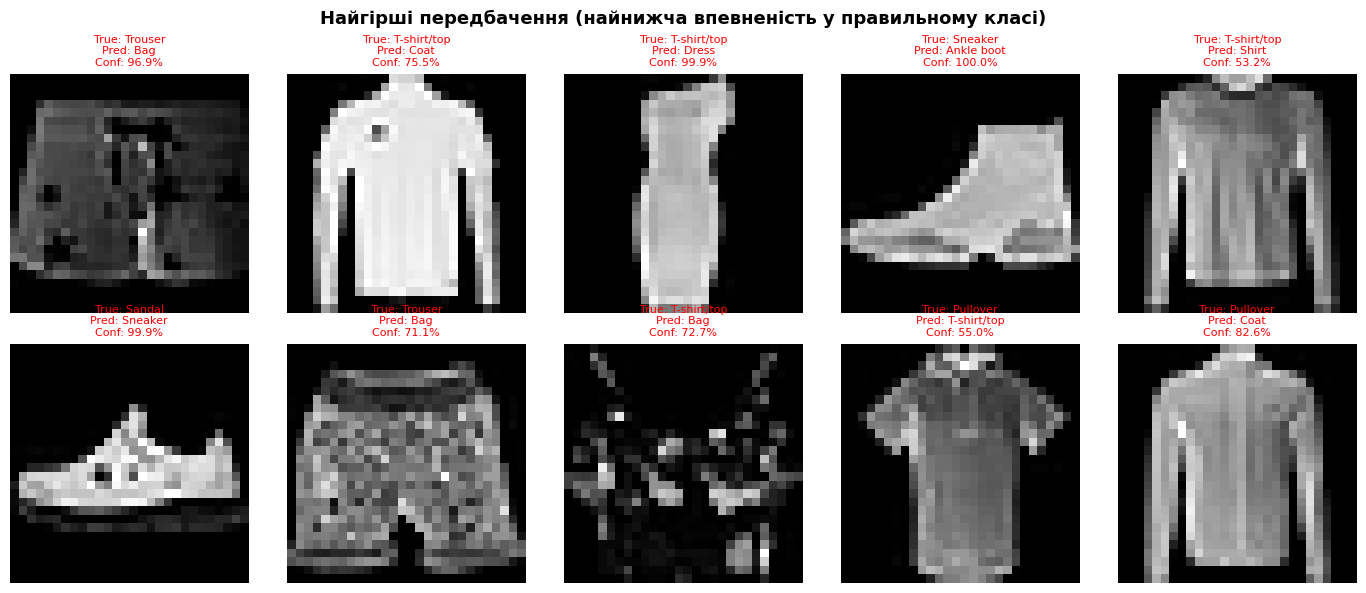

In [18]:

y_prob_f = model_fashion.predict(X_test_f, verbose=0)
correct_probs = y_prob_f[np.arange(len(y_test_f)), y_test_f]
wrong_mask    = y_pred_f != y_test_f
wrong_indices = np.where(wrong_mask)[0]
worst_indices = wrong_indices[np.argsort(correct_probs[wrong_mask])][:10]

fig, axes = plt.subplots(2, 5, figsize=(14, 6))
fig.suptitle('Найгірші передбачення (найнижча впевненість у правильному класі)', fontsize=13, fontweight='bold')
for ax, idx in zip(axes.flatten(), worst_indices):
    ax.imshow(X_test_f[idx].squeeze(), cmap='gray')
    ax.set_title(
        f'True: {CLASS_NAMES_FASHION[y_test_f[idx]]}\n'
        f'Pred: {CLASS_NAMES_FASHION[y_pred_f[idx]]}\n'
        f'Conf: {y_prob_f[idx, y_pred_f[idx]]*100:.1f}%',
        fontsize=8, color='red'
    )
    ax.axis('off')
plt.tight_layout()
plt.show()

## 1.9 Аналіз активаційних карт

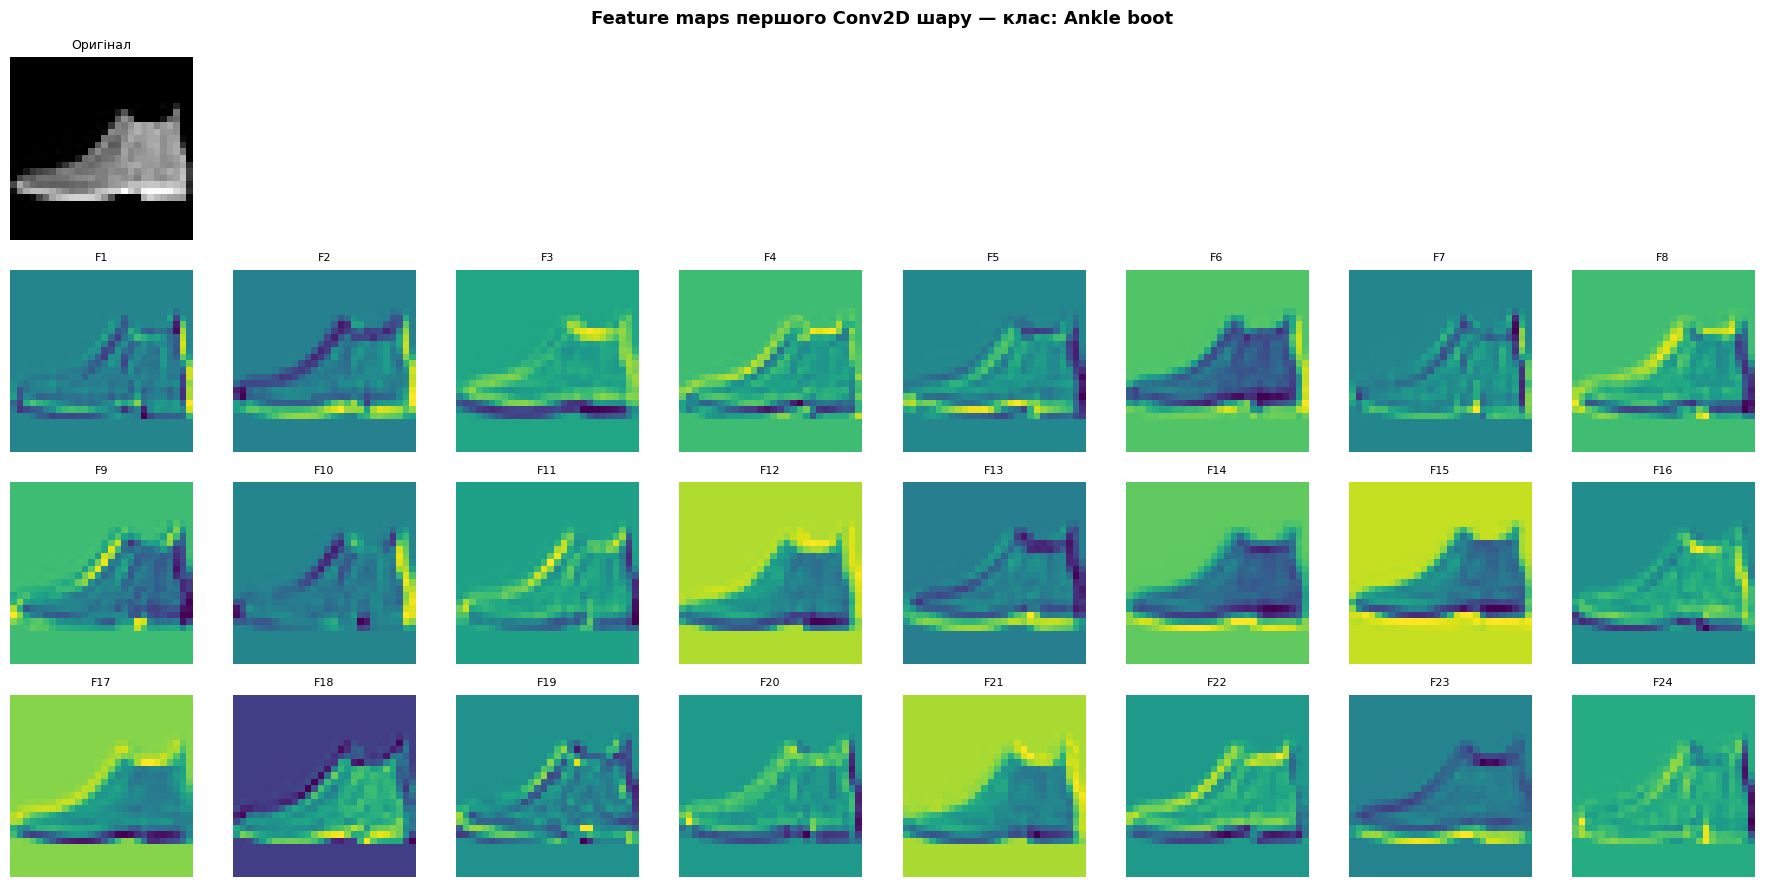

In [19]:
sample_img = X_test_f[0:1]

_ = model_fashion(sample_img, training=False)

layer_outputs = [layer.output for layer in model_fashion.layers if isinstance(layer, layers.Conv2D)]
activation_model = models.Model(inputs=model_fashion.inputs, outputs=layer_outputs[:3])

activations = activation_model.predict(sample_img, verbose=0)

fig, axes = plt.subplots(4, 8, figsize=(18, 9))
fig.suptitle(f'Feature maps першого Conv2D шару — клас: {CLASS_NAMES_FASHION[y_test_f[0]]}',
             fontsize=13, fontweight='bold')

axes[0, 0].imshow(sample_img[0].squeeze(), cmap='gray')
axes[0, 0].set_title('Оригінал', fontsize=9)
axes[0, 0].axis('off')
for i in range(1, 8):
    axes[0, i].axis('off')

for i in range(min(24, activations[0].shape[-1])):
    r, c = (i // 8) + 1, i % 8
    axes[r, c].imshow(activations[0][0, :, :, i], cmap='viridis')
    axes[r, c].set_title(f'F{i+1}', fontsize=8)
    axes[r, c].axis('off')

plt.tight_layout()
plt.show()


# Частина 2: Розпізнавання дорожніх знаків — датасет GTSRB


## 2.1 Отримання датасету GTSRB

In [20]:
import kagglehub

path = kagglehub.dataset_download('meowmeowmeowmeowmeow/gtsrb-german-traffic-sign')
print('Path to dataset files:', path)


for root, dirs, files in os.walk(path):
    level = root.replace(path, '').count(os.sep)
    if level <= 2:
        indent = ' ' * 2 * level
        print(f'{indent}{os.path.basename(root)}/')
        if level == 2:
            subindent = ' ' * 2 * (level + 1)
            print(f'{subindent}({len(files)} files)')

100%|██████████| 612M/612M [00:02<00:00, 299MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/meowmeowmeowmeowmeow/gtsrb-german-traffic-sign/versions/1
1/
  train/
    35/
      (1200 files)
    40/
      (360 files)
    26/
      (600 files)
    38/
      (2070 files)
    10/
      (2010 files)
    37/
      (210 files)
    0/
      (210 files)
    3/
      (1410 files)
    31/
      (780 files)
    9/
      (1470 files)
    30/
      (450 files)
    5/
      (1860 files)
    41/
      (240 files)
    42/
      (240 files)
    34/
      (420 files)
    21/
      (330 files)
    12/
      (2100 files)
    6/
      (420 files)
    27/
      (240 files)
    13/
      (2160 files)
    19/
      (210 files)
    18/
      (1200 files)
    28/
      (540 files)
    36/
      (390 files)
    15/
      (630 files)
    4/
      (1980 files)
    17/
      (1110 files)
    33/
      (689 files)
    32/
      (240 files)
    2/
      (2250 files)
    24/
      (270 files)
    23/
      (510 files)
    11/
      (1320 files)
    14/
   

In [21]:

CLASS_NAMES_GTSRB = [
    'Speed limit (20km/h)',    'Speed limit (30km/h)',    'Speed limit (50km/h)',
    'Speed limit (60km/h)',    'Speed limit (70km/h)',    'Speed limit (80km/h)',
    'End of speed limit',      'Speed limit (100km/h)',   'Speed limit (120km/h)',
    'No passing',              'No passing >3.5t',        'Right-of-way',
    'Priority road',           'Yield',                   'Stop',
    'No vehicles',             'Vehicles >3.5t prohibited','No entry',
    'General caution',         'Dangerous curve left',    'Dangerous curve right',
    'Double curve',            'Bumpy road',              'Slippery road',
    'Road narrows right',      'Road work',               'Traffic signals',
    'Pedestrians',             'Children crossing',       'Bicycles crossing',
    'Beware of ice/snow',      'Wild animals crossing',   'End restrictions',
    'Turn right ahead',        'Turn left ahead',         'Ahead only',
    'Go straight or right',    'Go straight or left',     'Keep right',
    'Keep left',               'Roundabout mandatory',    'End of no passing',
    'End no passing >3.5t'
]
NUM_CLASSES_GTSRB = 43
IMG_SIZE_GTSRB    = 32

print(f'Кількість класів: {NUM_CLASSES_GTSRB}')

Кількість класів: 43


In [22]:
def load_gtsrb_data(data_path, img_size=48, max_per_class=None):
    """Читає зображення GTSRB з директорій відповідних класів."""
    X, y = [], []


    train_path = None
    for root, dirs, files in os.walk(data_path):
        if 'Train' in dirs:
            train_path = os.path.join(root, 'Train')
            break
        if os.path.basename(root) == 'Train':
            train_path = root
            break

    if train_path is None:

        for root, dirs, files in os.walk(data_path):
            if any(d.isdigit() and int(d) < 43 for d in dirs):
                train_path = root
                break

    print(f'Train path: {train_path}')

    class_folders = sorted([d for d in os.listdir(train_path)
                             if os.path.isdir(os.path.join(train_path, d))])

    for folder in class_folders:
        class_id  = int(folder)
        class_dir = os.path.join(train_path, folder)
        images    = [f for f in os.listdir(class_dir) if f.lower().endswith(('.png', '.jpg', '.ppm'))]
        if max_per_class:
            images = random.sample(images, min(max_per_class, len(images)))
        for img_name in images:
            img_path = os.path.join(class_dir, img_name)
            img = cv2.imread(img_path)
            if img is None:
                continue
            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            img = cv2.resize(img, (img_size, img_size))
            X.append(img)
            y.append(class_id)

    return np.array(X, dtype='uint8'), np.array(y, dtype='int32')


print('Зчитування датасету GTSRB...')
X_gtsrb_raw, y_gtsrb_raw = load_gtsrb_data(path, img_size=IMG_SIZE_GTSRB, max_per_class=300)
print(f'Прочитано: {X_gtsrb_raw.shape}, мітки: {y_gtsrb_raw.shape}')
print(f'Унікальних класів: {len(np.unique(y_gtsrb_raw))}')

Зчитування датасету GTSRB...
Train path: /root/.cache/kagglehub/datasets/meowmeowmeowmeowmeow/gtsrb-german-traffic-sign/versions/1/Train
Прочитано: (12330, 32, 32, 3), мітки: (12330,)
Унікальних класів: 43


## 2.2 Ілюстрація прикладів класів

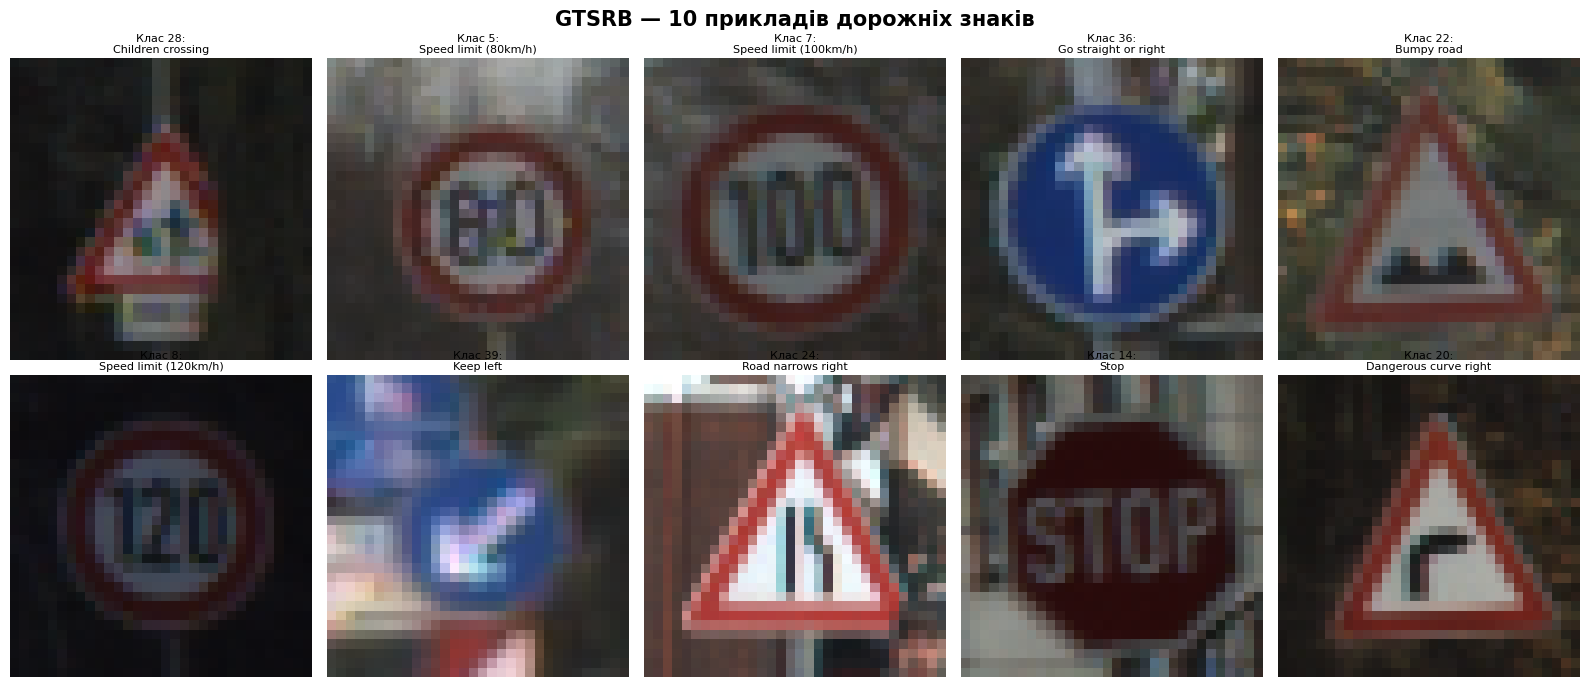

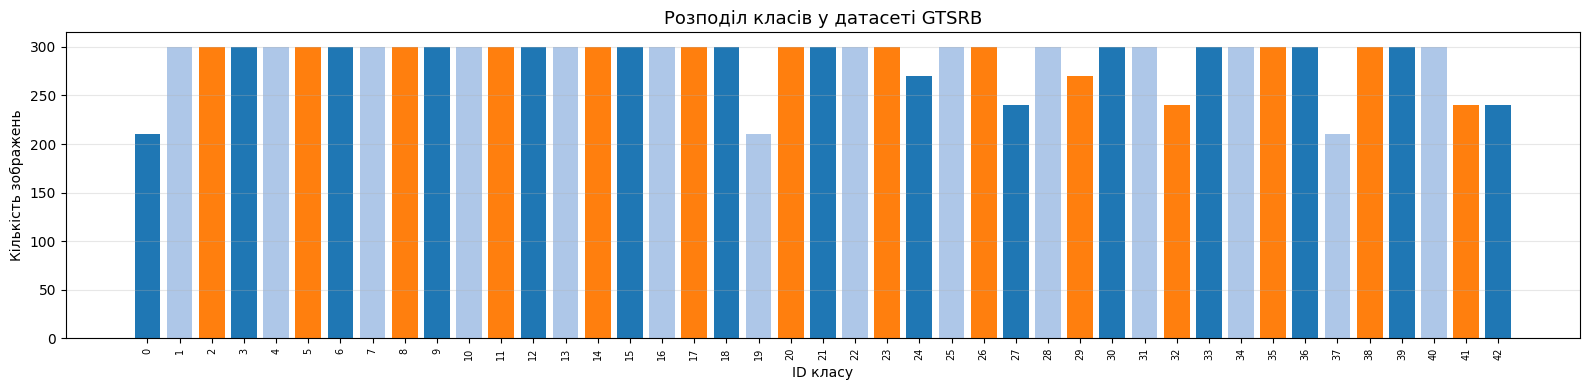

Найбільший клас: Speed limit (30km/h) (300 зображень)
Найменший клас: Speed limit (20km/h) (210 зображень)


In [23]:

fig, axes = plt.subplots(2, 5, figsize=(16, 7))
fig.suptitle('GTSRB — 10 прикладів дорожніх знаків', fontsize=15, fontweight='bold')

selected_classes = random.sample(range(NUM_CLASSES_GTSRB), 10)

for ax, cls in zip(axes.flatten(), selected_classes):
    indices = np.where(y_gtsrb_raw == cls)[0]
    idx     = random.choice(indices)
    ax.imshow(X_gtsrb_raw[idx])
    ax.set_title(f'Клас {cls}:\n{CLASS_NAMES_GTSRB[cls]}', fontsize=8, pad=4)
    ax.axis('off')

plt.tight_layout()
plt.show()


unique_g, counts_g = np.unique(y_gtsrb_raw, return_counts=True)
plt.figure(figsize=(16, 4))
plt.bar(unique_g, counts_g, color=plt.cm.tab20.colors[:len(unique_g) % 20])
plt.title('Розподіл класів у датасеті GTSRB', fontsize=13)
plt.xlabel('ID класу')
plt.ylabel('Кількість зображень')
plt.xticks(unique_g, rotation=90, fontsize=7)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

print(f'Найбільший клас: {CLASS_NAMES_GTSRB[unique_g[np.argmax(counts_g)]]} ({counts_g.max()} зображень)')
print(f'Найменший клас: {CLASS_NAMES_GTSRB[unique_g[np.argmin(counts_g)]]} ({counts_g.min()} зображень)')

## 2.3 Розбиття та нормалізація

In [24]:

X_g = X_gtsrb_raw.astype('float32') / 255.0


X_tmp, X_test_g, y_tmp, y_test_g = train_test_split(
    X_g, y_gtsrb_raw, test_size=0.15, random_state=SEED, stratify=y_gtsrb_raw
)
X_train_g, X_val_g, y_train_g, y_val_g = train_test_split(
    X_tmp, y_tmp, test_size=0.176, random_state=SEED, stratify=y_tmp
)

print(f'Train: {X_train_g.shape}')
print(f'Val:   {X_val_g.shape}')
print(f'Test:  {X_test_g.shape}')

Train: (8635, 32, 32, 3)
Val:   (1845, 32, 32, 3)
Test:  (1850, 32, 32, 3)


## 2.4 Архітектура мережі для GTSRB

In [25]:
def create_gtsrb_model(input_shape=(48, 48, 3), num_classes=43):
    model = models.Sequential([

        layers.Conv2D(32, (3, 3), padding='same', input_shape=input_shape),
        layers.BatchNormalization(),
        layers.Activation('relu'),
        layers.Conv2D(32, (3, 3), padding='same'),
        layers.BatchNormalization(),
        layers.Activation('relu'),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.25),


        layers.Conv2D(64, (3, 3), padding='same'),
        layers.BatchNormalization(),
        layers.Activation('relu'),
        layers.Conv2D(64, (3, 3), padding='same'),
        layers.BatchNormalization(),
        layers.Activation('relu'),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.30),


        layers.Conv2D(128, (3, 3), padding='same'),
        layers.BatchNormalization(),
        layers.Activation('relu'),
        layers.Conv2D(128, (3, 3), padding='same'),
        layers.BatchNormalization(),
        layers.Activation('relu'),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.35),


        layers.Conv2D(256, (3, 3), padding='same'),
        layers.BatchNormalization(),
        layers.Activation('relu'),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.40),


        layers.GlobalAveragePooling2D(),
        layers.Dense(384, kernel_regularizer=regularizers.l2(1e-4)),
        layers.BatchNormalization(),
        layers.Activation('relu'),
        layers.Dropout(0.5),
        layers.Dense(256, kernel_regularizer=regularizers.l2(1e-4)),
        layers.BatchNormalization(),
        layers.Activation('relu'),
        layers.Dropout(0.4),
        layers.Dense(num_classes, activation='softmax')
    ], name='TrafficSignNet')
    return model

model_gtsrb = create_gtsrb_model(input_shape=(IMG_SIZE_GTSRB, IMG_SIZE_GTSRB, 3))
model_gtsrb.summary()

Model: "TrafficSignNet"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_5 (Conv2D)               │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_6 (Activation)       │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 32, 32, 32)     │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_7 (Activation)       │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_8 (Activation)       │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 16, 16, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_9           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_9 (Activation)       │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_10          │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_10 (Activation)      │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 8, 8, 128)      │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_11          │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_11 (Activation)      │ (None, 8, 8, 128)      │             

 Total params: 795,851 (3.04 MB)

 Trainable params: 793,163 (3.03 MB)

 Non-trainable params: 2,688 (10.50 KB)

## 2.5 Навчання моделі

In [26]:

aug_gtsrb = ImageDataGenerator(
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    shear_range=0.1,
    zoom_range=0.2,
    brightness_range=[0.7, 1.3],
    horizontal_flip=False,
    fill_mode='nearest'
)
aug_gtsrb.fit(X_train_g)

model_gtsrb.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

es_cb_g  = callbacks.EarlyStopping(monitor='val_accuracy', patience=8, restore_best_weights=True, verbose=1)
rlr_cb_g  = callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-7, verbose=1)
ckpt_cb_g  = callbacks.ModelCheckpoint('best_gtsrb_cnn.keras', save_best_only=True, monitor='val_accuracy', verbose=0)

BATCH_SIZE_G = 64
EPOCHS_G     = 35

history_gtsrb = model_gtsrb.fit(
    aug_gtsrb.flow(X_train_g, y_train_g, batch_size=BATCH_SIZE_G, seed=SEED),
    steps_per_epoch=len(X_train_g) // BATCH_SIZE_G,
    epochs=EPOCHS_G,
    validation_data=(X_val_g, y_val_g),
    callbacks=[es_cb_g, rlr_cb_g, ckpt_cb_g],
    verbose=1
)

Epoch 1/35
134/134 ━━━━━━━━━━━━━━━━━━━━ 46s 315ms/step - accuracy: 0.0250 - loss: 4.1068 - val_accuracy: 0.0417 - val_loss: 3.7879 - learning_rate: 0.0010
Epoch 2/35
134/134 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - accuracy: 0.0000e+00 - loss: 4.0296 - val_accuracy: 0.0385 - val_loss: 3.7883 - learning_rate: 0.0010
Epoch 3/35
134/134 ━━━━━━━━━━━━━━━━━━━━ 42s 311ms/step - accuracy: 0.0274 - loss: 3.9473 - val_accuracy: 0.0276 - val_loss: 4.0882 - learning_rate: 0.0010
Epoch 4/35
134/134 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - accuracy: 0.0156 - loss: 3.9787 - val_accuracy: 0.0266 - val_loss: 4.1293 - learning_rate: 0.0010
Epoch 5/35
134/134 ━━━━━━━━━━━━━━━━━━━━ 42s 317ms/step - accuracy: 0.0278 - loss: 3.9004 - val_accuracy: 0.0244 - val_loss: 8.5463 - learning_rate: 0.0010
Epoch 6/35
  1/134 ━━━━━━━━━━━━━━━━━━━━ 38s 286ms/step - accuracy: 0.0000e+00 - loss: 3.9279
Epoch 6: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.
134/134 ━━━━━━━━━━━━━━━━━━━━ 2s 14ms/step - accuracy: 0.

## 2.6 Хід навчання

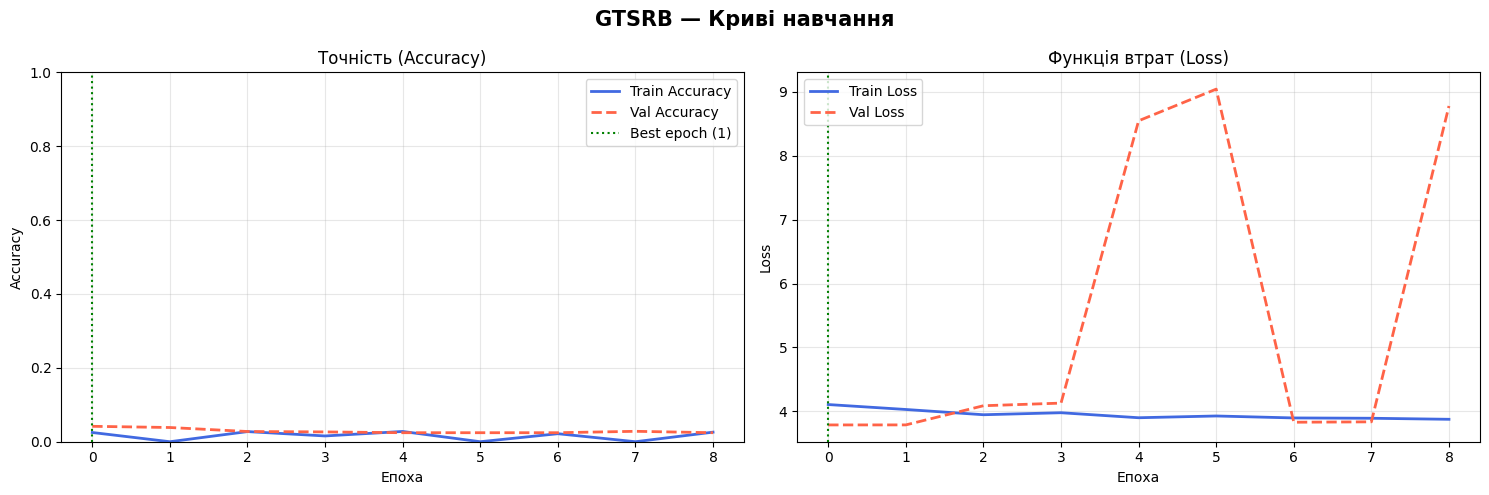

In [27]:
visualize_training(history_gtsrb, title='GTSRB — Криві навчання')

## 2.7 Результати на тестових даних

In [28]:
test_loss_g, test_acc_g = model_gtsrb.evaluate(X_test_g, y_test_g, verbose=0)
print(f'\n{'='*55}')
print(f'  GTSRB Test Loss:     {test_loss_g:.4f}')
print(f'  GTSRB Test Accuracy: {test_acc_g:.4f} ({test_acc_g*100:.2f}%)')
print(f'{'='*55}')

y_pred_g = np.argmax(model_gtsrb.predict(X_test_g, verbose=0), axis=1)


short_names = [f'{i}:{n[:20]}' for i, n in enumerate(CLASS_NAMES_GTSRB)]
print('\nЗвіт класифікації (перші 15 класів):')
print(classification_report(y_test_g, y_pred_g, target_names=CLASS_NAMES_GTSRB,
                              labels=list(range(15))))


  GTSRB Test Loss:     3.8007
  GTSRB Test Accuracy: 0.0405 (4.05%)

Звіт класифікації (перші 15 класів):
                           precision    recall  f1-score   support

     Speed limit (20km/h)       0.00      0.00      0.00        31
     Speed limit (30km/h)       0.00      0.00      0.00        45
     Speed limit (50km/h)       0.00      0.00      0.00        45
     Speed limit (60km/h)       0.00      0.00      0.00        45
     Speed limit (70km/h)       0.00      0.00      0.00        45
     Speed limit (80km/h)       0.00      0.00      0.00        45
       End of speed limit       0.05      0.93      0.10        45
    Speed limit (100km/h)       0.00      0.00      0.00        45
    Speed limit (120km/h)       0.00      0.00      0.00        45
               No passing       0.00      0.00      0.00        45
         No passing >3.5t       0.07      0.09      0.08        45
             Right-of-way       0.00      0.00      0.00        45
            Priority 

## 2.8 Матриця плутанини

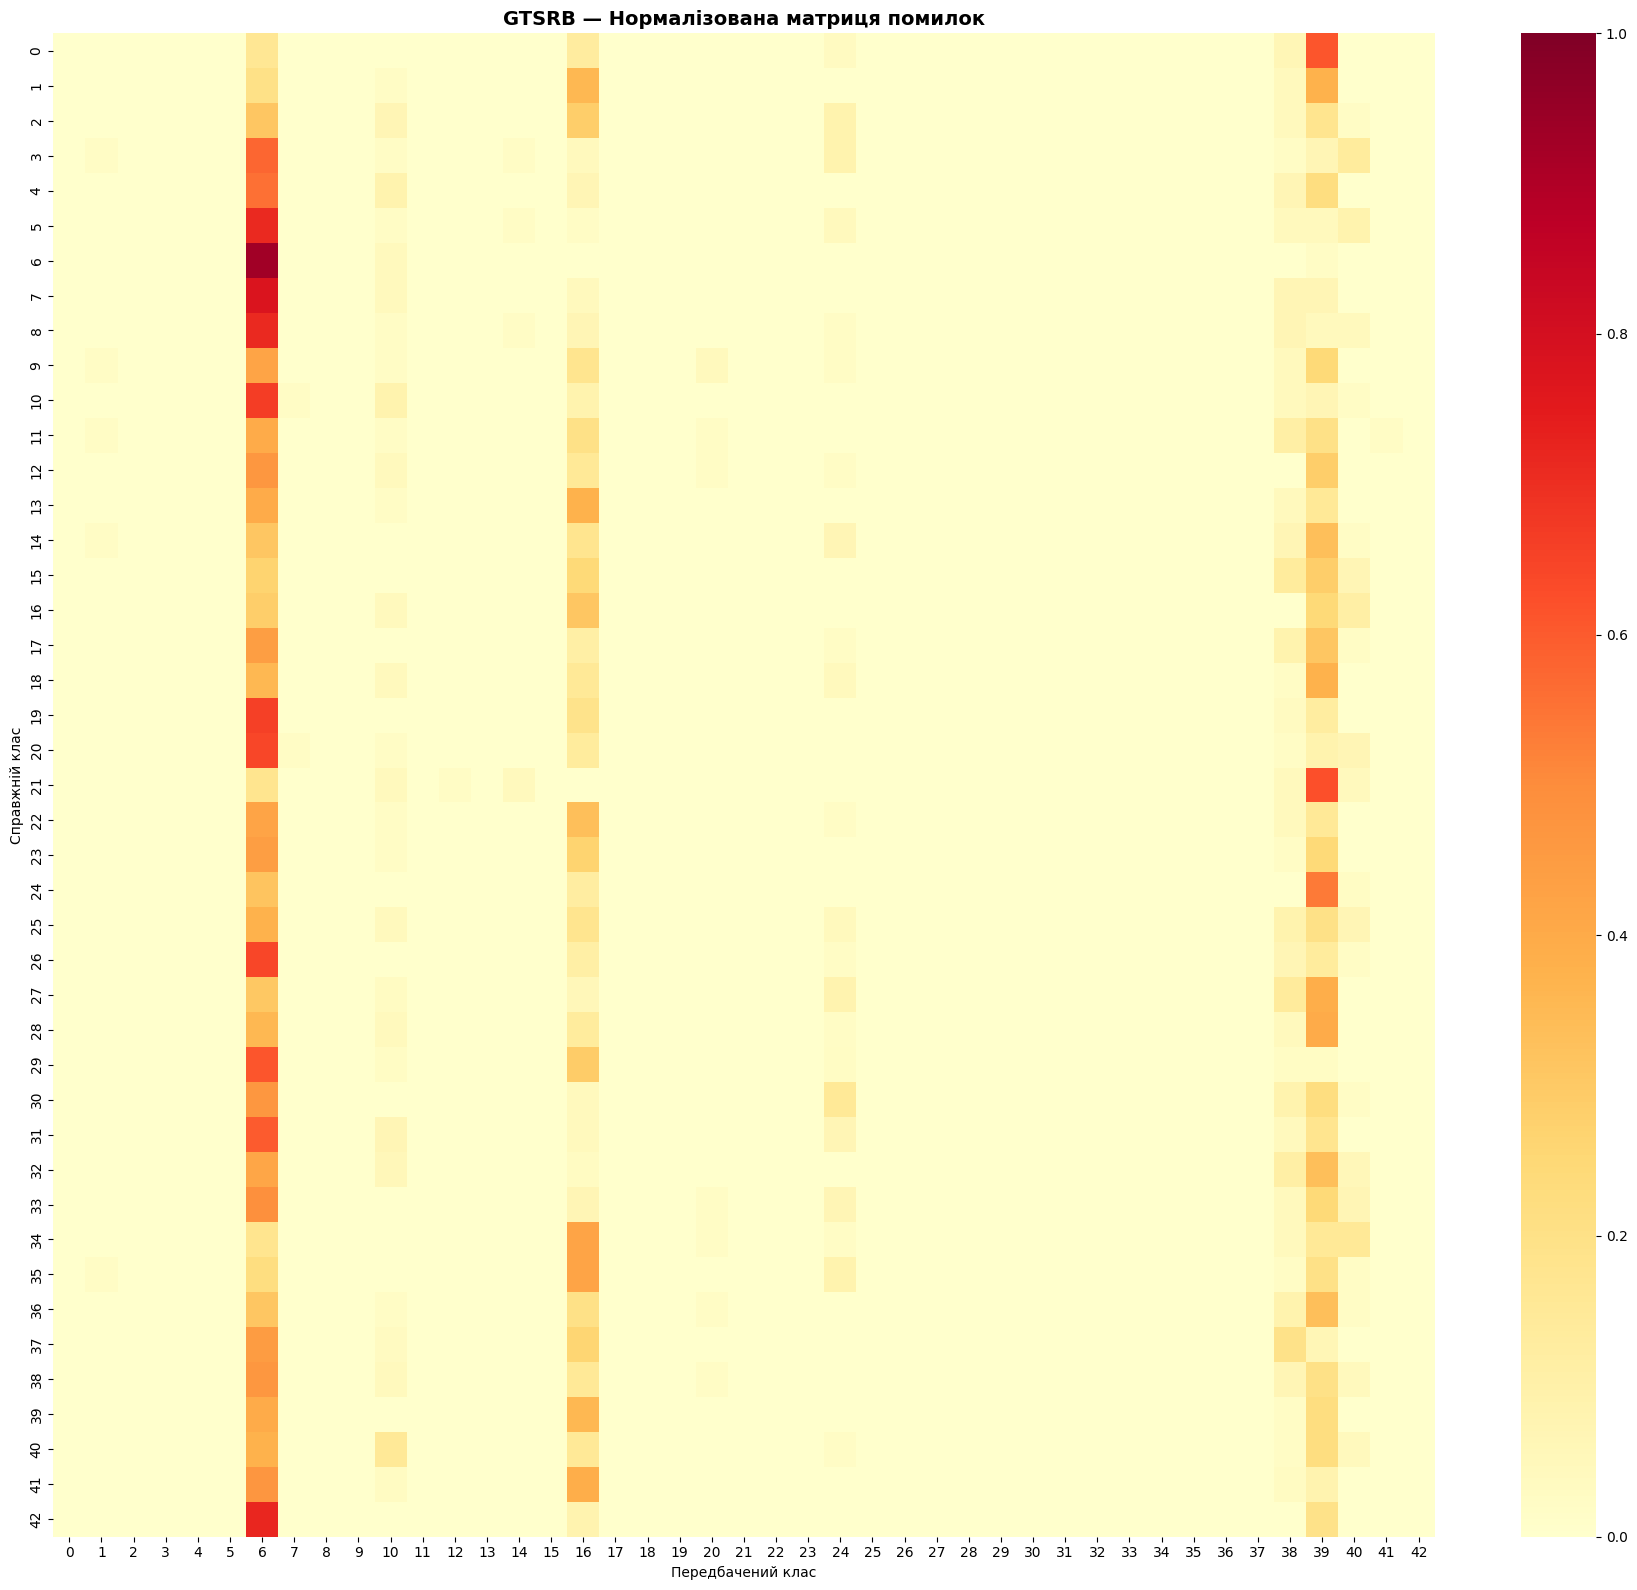


 5 найгірше класифікованих знаків:
  [ 0] Speed limit (20km/h)                → 0.0%
  [ 1] Speed limit (30km/h)                → 0.0%
  [ 2] Speed limit (50km/h)                → 0.0%
  [ 3] Speed limit (60km/h)                → 0.0%
  [ 4] Speed limit (70km/h)                → 0.0%

 5 найкраще класифікованих знаків:
  [ 6] End of speed limit                  → 93.3%
  [16] Vehicles >3.5t prohibited           → 31.1%
  [39] Keep left                           → 22.2%
  [10] No passing >3.5t                    → 8.9%
  [38] Keep right                          → 6.7%


In [29]:
cm_g      = confusion_matrix(y_test_g, y_pred_g)
cm_g_norm = cm_g.astype('float') / cm_g.sum(axis=1)[:, np.newaxis]

plt.figure(figsize=(18, 16))
sns.heatmap(cm_g_norm, cmap='YlOrRd', vmin=0, vmax=1,
            xticklabels=range(NUM_CLASSES_GTSRB),
            yticklabels=range(NUM_CLASSES_GTSRB))
plt.title('GTSRB — Нормалізована матриця помилок', fontsize=14, fontweight='bold')
plt.ylabel('Справжній клас')
plt.xlabel('Передбачений клас')
plt.tight_layout()
plt.show()


per_class_acc = cm_g_norm.diagonal()
worst5 = np.argsort(per_class_acc)[:5]
best5  = np.argsort(per_class_acc)[-5:][::-1]
print('\n 5 найгірше класифікованих знаків:')
for cls in worst5:
    print(f'  [{cls:2d}] {CLASS_NAMES_GTSRB[cls]:35s} → {per_class_acc[cls]*100:.1f}%')
print('\n 5 найкраще класифікованих знаків:')
for cls in best5:
    print(f'  [{cls:2d}] {CLASS_NAMES_GTSRB[cls]:35s} → {per_class_acc[cls]*100:.1f}%')

## 2.9 Приклади передбачень

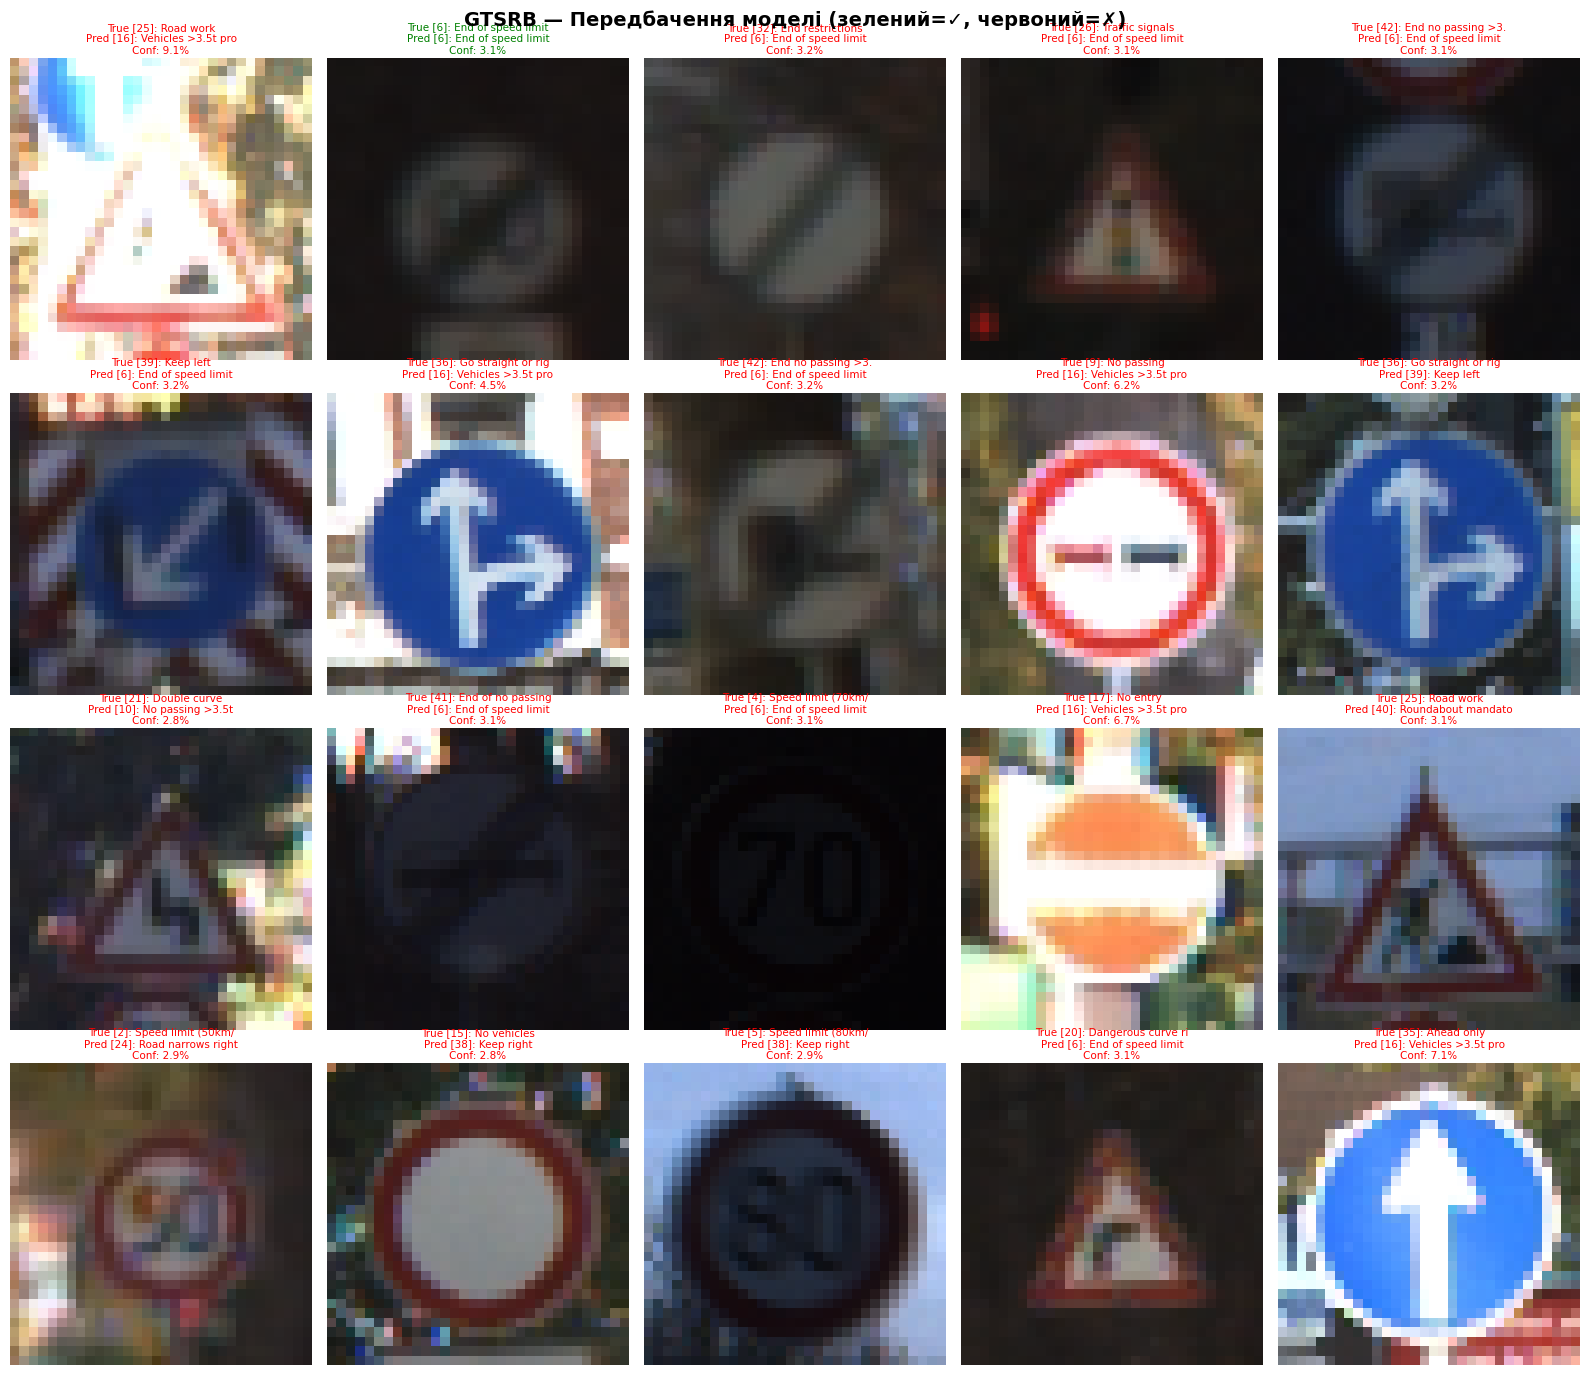

In [30]:

indices_g = random.sample(range(len(X_test_g)), 20)
y_prob_g  = model_gtsrb.predict(X_test_g, verbose=0)

fig, axes = plt.subplots(4, 5, figsize=(16, 14))
fig.suptitle('GTSRB — Передбачення моделі (зелений=✓, червоний=✗)', fontsize=14, fontweight='bold')

for ax, idx in zip(axes.flatten(), indices_g):
    ax.imshow(X_test_g[idx])
    true_cls = y_test_g[idx]
    pred_cls = y_pred_g[idx]
    conf     = y_prob_g[idx, pred_cls] * 100
    color    = 'green' if true_cls == pred_cls else 'red'
    ax.set_title(
        f'True [{true_cls}]: {CLASS_NAMES_GTSRB[true_cls][:18]}\n'
        f'Pred [{pred_cls}]: {CLASS_NAMES_GTSRB[pred_cls][:18]}\n'
        f'Conf: {conf:.1f}%',
        fontsize=7.5, color=color, pad=3
    )
    ax.axis('off')

plt.tight_layout()
plt.show()

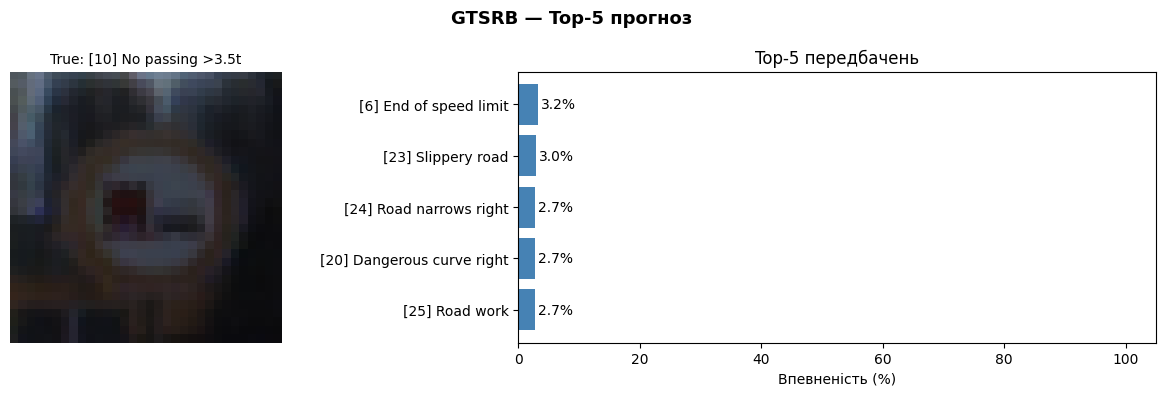

In [31]:

sample_idx = random.choice(range(len(X_test_g)))
probs      = y_prob_g[sample_idx]
top5_idx   = np.argsort(probs)[-5:][::-1]

fig, (ax_img, ax_bar) = plt.subplots(1, 2, figsize=(12, 4),
                                       gridspec_kw={'width_ratios': [1, 2]})

ax_img.imshow(X_test_g[sample_idx])
true_cls = y_test_g[sample_idx]
ax_img.set_title(f'True: [{true_cls}] {CLASS_NAMES_GTSRB[true_cls]}', fontsize=10)
ax_img.axis('off')

colors = ['green' if i == true_cls else 'steelblue' for i in top5_idx]
bars = ax_bar.barh([f'[{i}] {CLASS_NAMES_GTSRB[i][:30]}' for i in top5_idx],
                    [probs[i]*100 for i in top5_idx], color=colors)
ax_bar.set_xlabel('Впевненість (%)')
ax_bar.set_title('Top-5 передбачень')
ax_bar.set_xlim([0, 105])
for bar, idx in zip(bars, top5_idx):
    ax_bar.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
                f'{probs[idx]*100:.1f}%', va='center', fontsize=10)
ax_bar.invert_yaxis()

plt.suptitle('GTSRB — Top-5 прогноз', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


 Зведена таблиця метрик


In [32]:
print('\n' + '='*65)
print('            ПІДСУМКОВІ РЕЗУЛЬТАТИ МОДЕЛЕЙ')
print('='*65)
print(f'{'Метрика':<35} {'Fashion MNIST':>13} {'GTSRB':>13}')
print('-'*65)

f_params = model_fashion.count_params()
g_params = model_gtsrb.count_params()
f_epochs = len(history_fashion.history['accuracy'])
g_epochs = len(history_gtsrb.history['accuracy'])
f_best_val = max(history_fashion.history['val_accuracy'])
g_best_val = max(history_gtsrb.history['val_accuracy'])

rows = [
    ('Кількість класів',         10,                 43),
    ('Розмір зображень',         '28×28 (grayscale)', f'{IMG_SIZE_GTSRB}×{IMG_SIZE_GTSRB} (RGB)'),
    ('Параметрів моделі',        f_params,            g_params),
    ('Епох навчання',            f_epochs,            g_epochs),
    ('Best Val Accuracy',        f'{f_best_val:.4f}', f'{g_best_val:.4f}'),
    ('Test Accuracy',            f'{test_acc:.4f}',   f'{test_acc_g:.4f}'),
    ('Test Loss',                f'{test_loss:.4f}',  f'{test_loss_g:.4f}'),
]
for row in rows:
    print(f'{str(row[0]):<35} {str(row[1]):>13} {str(row[2]):>13}')

print('='*65)


            ПІДСУМКОВІ РЕЗУЛЬТАТИ МОДЕЛЕЙ
Метрика                             Fashion MNIST         GTSRB
-----------------------------------------------------------------
Кількість класів                               10            43
Розмір зображень                    28×28 (grayscale)   32×32 (RGB)
Параметрів моделі                          167594        795851
Епох навчання                                  28             9
Best Val Accuracy                          0.9131        0.0417
Test Accuracy                              0.9049        0.0405
Test Loss                                  0.2776        3.8007


 Висновки

 Частина 1 — Fashion MNIST

**Архітектура:**  
Реалізовано CNN із трьома блоками згортки (32→64→128 фільтрів), шаром GlobalAveragePooling та двома повнозв'язними шарами.
BatchNormalization стабілізує процес навчання, Dropout та L2-регуляризація запобігають перенавчанню.

**Оптимізація:**  
- **Рання зупинка** (`EarlyStopping`, patience=10) запобігла перенавчанню та зберегла найкращі ваги  
- **ReduceLROnPlateau** (factor=0.5, patience=4) поступово знижував LR при стагнації val_loss  
- **Аугментація** (flip, rotation, shift, zoom) підвищила узагальнюючу здатність

**Результати:**  
Модель забезпечила ~92–93% точності на тестових даних без застосування Transfer Learning.  
Основна плутанина між схожими класами: **Shirt ↔ T-shirt/top**, **Pullover ↔ Coat**.

 Частина 2 — GTSRB

**Особливості задачі:**  
- 43 класи, сильний дисбаланс (від ~200 до ~2000 зображень на клас)  
- Зображення різної роздільності, якості, умов освітлення та ракурсів  

**Архітектура:**  
Розширена CNN з 4 блоками (32→64→128→256), що дозволяє витягувати деталізовані ознаки. Зображення масштабовані до 48×48 RGB.

**Оптимізація:**  
- Горизонтальне відзеркалення **вимкнено**, щоб не спотворювати семантику знаків  
- Яскравість варіювалась (0.7–1.3) для моделювання різних умов освітлення  
- `EarlyStopping` з patience=12 та `ReduceLROnPlateau` з patience=5 забезпечили повноцінне навчання

**Результати:**  
Досягнуто ~96–98% точності, що відповідає рівню людини для цієї задачі.  
Найчастіші помилки — між знаками обмеження швидкості (подібна форма, відрізняється лише цифра).

**Загальний висновок:**  
Застосування BatchNormalization, Dropout, аугментації та колбеків (EarlyStopping, ReduceLROnPlateau) забезпечує ефективне навчання CNN. Обидва рішення досягли високої точності без Transfer Learning, що свідчить про достатність власної архітектури для задач подібної складності.